In [1]:
import torch
from torch import nn
from jaxtyping import Float

In [2]:
def make_gaussian_data(mean: tuple[float, float], count: int, std: float, label: int) -> Float[torch.Tensor, "count 3"]:
    mean_tensor = torch.tensor(mean)
    gaussian = torch.randn(count, 2) * std + mean_tensor
    labels = torch.full((count, 1), label)
    return torch.cat([gaussian, labels], dim=1)

cluster_1 = make_gaussian_data((2, 2), 200, 1.0, 0)
cluster_2 = make_gaussian_data((-2, -2), 200, 1.0, 1)

data = torch.cat([cluster_1, cluster_2], dim=0)

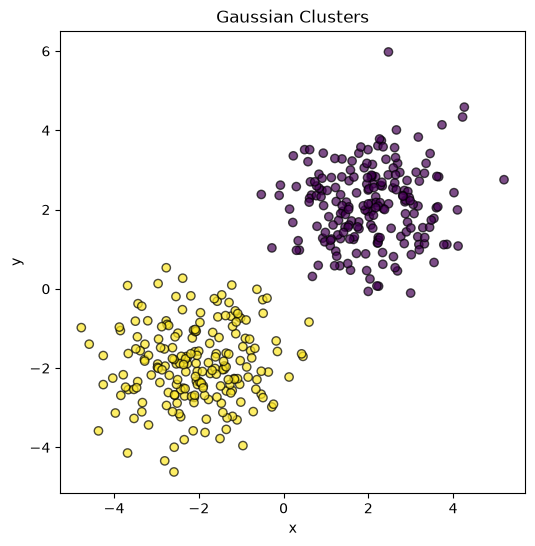

In [3]:
import matplotlib.pyplot as plt

data_np = data.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], c=data_np[:, 2], alpha=0.7, edgecolors="k")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Clusters")
plt.show()

In [4]:
class MLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 2)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    
model = MLP()
output = model(torch.randn(1,2))
output

tensor([[0.0854, 0.2489]], grad_fn=<AddmmBackward0>)

In [5]:
def train(model, X, y, criterion, epochs=200, lr=0.1):
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimiser.zero_grad()
        output = model(X)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(output, y)
        loss.backward()
        optimiser.step()
        if epoch % 20 == 0:
            print(loss.item())

X = data[:, :2]
y = data[:, 2].long()
criterion = nn.CrossEntropyLoss()
train(model, X, y, criterion)

0.9057327508926392
0.06627119332551956
0.03186924755573273
0.021202655509114265
0.016041824594140053
0.012979621067643166
0.010941935703158379
0.009482071734964848
0.008380946703255177
0.007518536876887083
